# 9.5.2 留出预测覆盖与模型失配

## 学习目标与先修知识

比较预测分数与覆盖的抽样波动，识别近似失误和机制失配。

先修：9.1的清除参数（parameter）模型（model），9.2的接受比，9.3的ELBO，9.5.1的混合预测。

## 具体问题

同一组清除读数得到的后验（posterior），用积分、采样（sampling）和变分计算后，预测有多大差异？当新条件增加了未建模输入（input）时，更多计算能否修复共同偏差？先封存预测，再生成评估观测（observation）。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

20次独立评估覆盖18次，样本比例为90%，但它并不是无误差的总体概率（probability）。

In [2]:
n=20;coverage=18/n
print("覆盖比例与插件标准误：",coverage,math.sqrt(coverage*(1-coverage)/n))

覆盖比例与插件标准误： 0.9 0.06708203932499368


## 模型假设

训练时A(t)=5 exp(−kt)，k>0；先验（prior）为形状2、率4的Gamma分布（distribution）；观测噪声为独立零均值高斯，方差（variance）r=.16 U²。t以T计、k以1/T计，计算使用这些单位下的数值。四个训练读数固定不变。新观测在t=5 T获得，不参与后验或算法设置。比较先对齐先验、似然（likelihood）、数据和预测目标，再分别报告密度评估预算；本例没有强称不同预算下的速度优劣。

## 数学解释与推导

在9.1的负对数未归一化后验$f(k)$下，正参数变换$\eta=\log k$给出$\log\tilde p_\eta(\eta)=-f(e^\eta)+\eta$。这个加项既用于MH接受比，也用于变分期望（expectation），不能因为它不含观测而删去。

选择$q_\eta=N(m,s^2)$，其熵（entropy）为$\tfrac12\log(2\pi e s^2)$，因而
$$\mathcal L(m,s)=E_q[-f(e^\eta)+\eta]+\tfrac12\log(2\pi e s^2).$$
利用Gauss–Hermite求积（Gauss–Hermite quadrature），$E_q[g(\eta)]\approx\sum_j w_j g(m+\sqrt2s z_j)/\sqrt\pi$。这里以三轮缩小搜索网格显式寻找$(m,s)$；它不是全局优化保证。求积点数和搜索范围也会影响近似，须与加密积分参照检查。$f$省略的参数无关常数同时从证据和ELBO中省略，所以两者的差仍有KL意义；本节不报告绝对模型证据。

对预先封存的未来预测，均方误差检查均值，平均对数分数$N^{-1}\sum_i\log p(y_i^{test}\mid y)$检查整分布，覆盖比例$\hat c=N^{-1}\sum_i1\{l_i\le y_i^{test}\le u_i\}$检查区间。分数越大越好；固定同一U尺度。独立且同条件的覆盖指示量可用$\sqrt{\hat c(1-\hat c)/N}$描述抽样标准误（standard error）；小样本或边界比例应用二项区间。

若评估时从$t=0$起有恒定输入$u$，正确均值应为$5e^{-kt}+u(1-e^{-kt})/k$。故意仍用无输入预测，可以隔离“机制遗漏”与“近似计算误差”。误差来自遗漏的输入项，观测噪声保持原设定。

最后另做共轭模型的重复校准：每个场景重新从先验生成参数、生成训练与未来观测。正确模型的95%预测区间（prediction interval）在这种联合重复机制下具有95%覆盖；固定一个真实参数、固定一组训练数据后的条件覆盖则不必恰为95%。这两种重复对象不能混同。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def clearance_loss(rate,times,observations,initial,noise,shape,prior_rate):
    if rate<=0:return math.inf
    residuals=[initial*math.exp(-rate*t)-y for t,y in zip(times,observations)]
    return sum(r*r for r in residuals)/(2*noise)+prior_rate*rate-(shape-1)*math.log(rate)


def logsumexp(values):
    top=max(values)
    return top+math.log(sum(math.exp(x-top) for x in values))


def grid_posterior(nodes,log_values):
    # Trapezoidal integration: endpoint nodes receive half interval weights.
    widths=[(nodes[1]-nodes[0])/2]+[(nodes[i+1]-nodes[i-1])/2 for i in range(1,len(nodes)-1)]+[(nodes[-1]-nodes[-2])/2]
    log_mass=[l+math.log(w) for l,w in zip(log_values,widths)]
    normalizer=logsumexp(log_mass)
    weights=[math.exp(l-normalizer) for l in log_mass]
    mean=sum(w*x for w,x in zip(weights,nodes))
    variance=sum(w*(x-mean)**2 for w,x in zip(weights,nodes))
    return weights,mean,variance,normalizer


def clearance_local(times,observations,initial,noise,shape,prior_rate,lower,upper):
    # Bracket the best coarse-grid basin, then minimize within that basin.
    nodes=[lower+(upper-lower)*i/1000 for i in range(1001)]
    loss=lambda k:clearance_loss(k,times,observations,initial,noise,shape,prior_rate)
    j=min(range(len(nodes)),key=lambda i:loss(nodes[i]))
    if j in (0,1000):raise ValueError('搜索边界可能截断模态，需要扩大范围')
    left,right=nodes[j-1],nodes[j+1]
    ratio=(math.sqrt(5)-1)/2
    for _ in range(70):
        x=right-ratio*(right-left);y=left+ratio*(right-left)
        if loss(x)<loss(y):right=y
        else:left=x
    mode=(left+right)/2
    curve=sum(t*t*(initial*math.exp(-mode*t))*(2*initial*math.exp(-mode*t)-y)/noise for t,y in zip(times,observations))+(shape-1)/mode**2
    if curve<=0:raise ValueError('曲率不能定义局部高斯方差')
    return mode,curve,1/curve


def clearance_variational(times,observations,initial,noise,shape,prior_rate):
    # eta=log(k) is Gaussian under q. Hermite quadrature approximates E_q.
    nodes,weights=np.polynomial.hermite.hermgauss(40)
    weights=weights/math.sqrt(math.pi);best=(-math.inf,None,None);evaluations=0
    mr=(-2.,0.);sr=(.05,.8)
    for stage in range(3):
        ms=np.linspace(*mr,25);ss=np.linspace(*sr,20)
        for m in ms:
            for s in ss:
                eta=m+math.sqrt(2)*s*nodes
                terms=[-clearance_loss(math.exp(x),times,observations,initial,noise,shape,prior_rate)+x for x in eta]
                bound=float(weights@terms)+.5*math.log(2*math.pi*math.e*s*s)
                evaluations+=len(nodes)
                if bound>best[0]:best=(bound,float(m),float(s))
        dm=ms[1]-ms[0];ds=ss[1]-ss[0]
        mr=(best[1]-dm,best[1]+dm);sr=(max(.005,best[2]-ds),best[2]+ds)
    return best[1],best[2],best[0],evaluations


def clearance_chain(times,observations,initial,noise,shape,prior_rate,start,increments,uniforms):
    eta=start;current=-clearance_loss(math.exp(eta),times,observations,initial,noise,shape,prior_rate)+eta
    states=[math.exp(eta)];accepted=0
    for increment,u in zip(increments,uniforms):
        candidate=eta+increment
        proposed=-clearance_loss(math.exp(candidate),times,observations,initial,noise,shape,prior_rate)+candidate
        if u==0 or math.log(u)<min(0,proposed-current):
            eta,current=candidate,proposed;accepted+=1
        states.append(math.exp(eta))
    return states,accepted/len(increments)


def mixture_quantile(probability,weights,means,variances):
    total=sum(weights);weights=[w/total for w in weights]
    def cdf(x):
        return sum(w*(1+math.erf((x-m)/math.sqrt(2*v)))/2 for w,m,v in zip(weights,means,variances))
    lo=min(m-12*math.sqrt(v) for m,v in zip(means,variances));hi=max(m+12*math.sqrt(v) for m,v in zip(means,variances))
    assert cdf(lo)<probability<cdf(hi)
    for _ in range(60):
        mid=(lo+hi)/2
        if cdf(mid)<probability:lo=mid
        else:hi=mid
    return (lo+hi)/2


def normal_logpdf(value,mean,variance):
    return -.5*(math.log(2*math.pi*variance)+(value-mean)**2/variance)


def predictive_score(observed,weights,means,variances,lower,upper,evaluations):
    total=sum(weights);w=[v/total for v in weights];count=len(observed)
    if count==0:return None,None,None,evaluations
    center=sum(p*m for p,m in zip(w,means));score=0.;covered=0
    for y,lo,hi in zip(observed,lower,upper):
        score+=logsumexp([math.log(p)+normal_logpdf(y,m,v) for p,m,v in zip(w,means,variances) if p>0])
        covered+=lo<=y<=hi
    return sum((y-center)**2 for y in observed)/count,score/count,covered/count,evaluations


def normal_update(prior_mean,prior_variance,observations,noise_variance):
    precision=1/prior_variance+len(observations)/noise_variance
    variance=1/precision
    mean=variance*(prior_mean/prior_variance+sum(observations)/noise_variance)
    return mean,variance,variance+noise_variance

## 对照实验

对齐四个训练观测，先构建并冻结MAP代入、积分、MH和对数高斯变分四种预测。MH使用种子9502、12000步和2000步预热；以10步间隔保留1000点仅为减轻绘图与求分位数开销，不宣称它们独立。之后才生成200个独立未来读数，原条件与遗漏输入条件共用相同噪声以便配对比较。

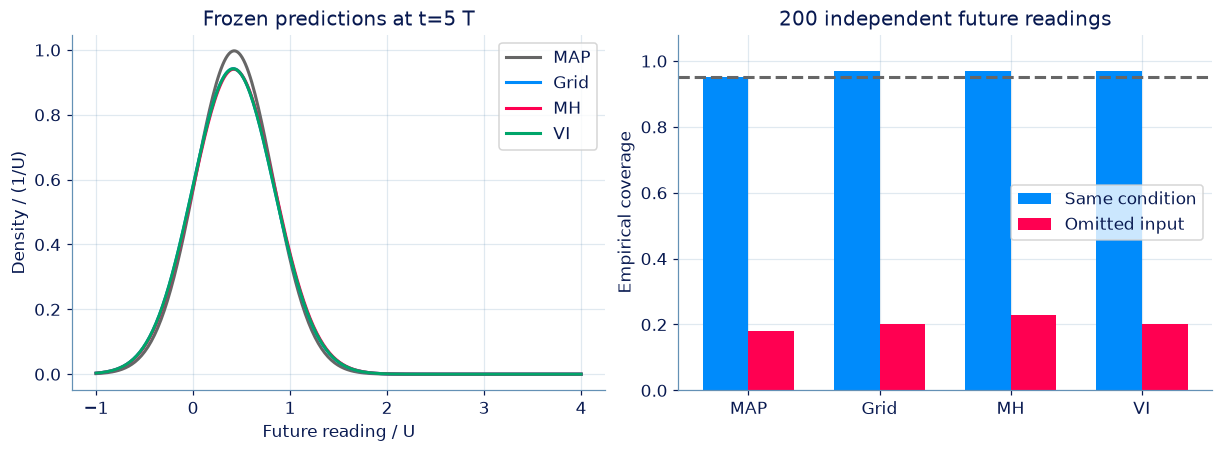

| 条件 | 方法 | MSE / U² | 平均log分数 | 覆盖比例 | 标准误 | 密度评估次数 |
| --- | --- | --- | --- | --- | --- | --- |
| Same condition | MAP | 0.162064 | -0.509098 | 0.95 | 0.015411 | 1141 |
| Same condition | Grid | 0.163467 | -0.516393 | 0.97 | 0.0120623 | 4001 |
| Same condition | MH | 0.162051 | -0.512551 | 0.97 | 0.0120623 | 12001 |
| Same condition | VI | 0.163489 | -0.516447 | 0.97 | 0.0120623 | 60000 |
| Omitted input | MAP | 1.42308 | -4.44978 | 0.18 | 0.0271662 | 1141 |
| Omitted input | Grid | 1.43446 | -3.98601 | 0.2 | 0.0282843 | 4001 |
| Omitted input | MH | 1.42297 | -3.95187 | 0.23 | 0.0297574 | 12001 |
| Omitted input | VI | 1.43464 | -3.98841 | 0.2 | 0.0282843 | 60000 |

MH接受率： 0.468 ；VI的logZ−ELBO： 6e-05


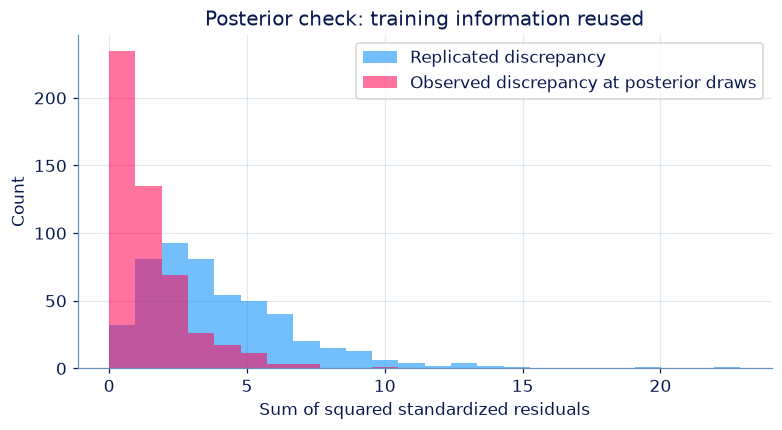

后验复制数据检查：500次；尾部比例= 0.83 ；模拟标准误= 0.017


In [4]:
times=[0.,1.,2.,3.];observed=[5.1,3.2,1.6,1.2];args=(times,observed,5.,.16,2.,4.)
nodes=np.linspace(.0001,4,4001);logp=[-clearance_loss(k,*args) for k in nodes]
w,grid_mean,grid_var,logZ=grid_posterior(nodes,logp)
mode,_,_=clearance_local(*args,.0001,4)
vm,vs,bound,vi_cost=clearance_variational(*args)
rng=np.random.default_rng(9502)
chain,acceptance=clearance_chain(*args,math.log(.5),rng.normal(0,.3,12000),rng.uniform(size=12000))
sample=np.array(chain[2001::10]);z,hw=np.polynomial.hermite.hermgauss(40)
methods={'MAP':([mode],[1.],1141),'Grid':(nodes,w,4001),'MH':(sample,np.ones(len(sample))/len(sample),12001),'VI':(np.exp(vm+math.sqrt(2)*vs*z),hw/math.sqrt(math.pi),vi_cost)}
predictions={};x=np.linspace(-1,4,300)
fig,axes=plt.subplots(1,2,figsize=(11,4));colors=["#666666",BLUE,PINK,GREEN]
for (name,(ks,ws,cost)),color in zip(methods.items(),colors):
    means=5*np.exp(-np.array(ks)*5);variances=np.full(len(ks),.16)
    interval=[mixture_quantile(p,ws,means,variances) for p in [.025,.975]]
    density=np.exp(-.5*(x[:,None]-means)**2/.16)/math.sqrt(2*math.pi*.16)@np.array(ws)
    predictions[name]=(ws,means,variances,interval,cost)
    axes[0].plot(x,density,color=color,label=name)
axes[0].set(xlabel='Future reading / U',ylabel='Density / (1/U)',title='Frozen predictions at t=5 T');axes[0].legend()
# Evaluation-only truth and noise are introduced after all predictions are fixed.
truth_rate=.45;noise=np.random.default_rng(9503).normal(0,.4,200)
same=5*math.exp(-truth_rate*5)+noise;shift=.5*(1-math.exp(-truth_rate*5))/truth_rate
new_input=same+shift;rows=[]
for condition,ys in [('Same condition',same),('Omitted input',new_input)]:
    for name,(ws,means,variances,(lo,hi),cost) in predictions.items():
        mse,score,cover,_=predictive_score(ys,ws,means,variances,[lo]*len(ys),[hi]*len(ys),cost)
        rows.append((condition,name,mse,score,cover,math.sqrt(cover*(1-cover)/len(ys)),cost))
for j,condition in enumerate(['Same condition','Omitted input']):
    result=[row[4] for row in rows if row[0]==condition]
    axes[1].bar(np.arange(4)+(j-.5)*.35,result,width=.35,label=condition,color=[BLUE,PINK][j])
axes[1].axhline(.95,color='#666666',ls='--');axes[1].set(xticks=np.arange(4),xticklabels=list(methods),ylim=(0,1.08),ylabel='Empirical coverage',title='200 independent future readings');axes[1].legend();plt.show()
display(Markdown(show_table(['条件','方法','MSE / U²','平均log分数','覆盖比例','标准误','密度评估次数'],rows)))
print('MH接受率：',round(acceptance,3),'；VI的logZ−ELBO：',round(logZ-bound,5))
# Posterior predictive check reuses training data: model check, not validation.
rng_check=np.random.default_rng(9505);rep_k=rng_check.choice(nodes,size=500,p=w)
rep_mean=5*np.exp(-rep_k[:,None]*np.array(times))
rep_y=rep_mean+rng_check.normal(0,.4,rep_mean.shape)
T_observed=np.sum((np.array(observed)-rep_mean)**2/.16,axis=1)
T_replicated=np.sum((rep_y-rep_mean)**2/.16,axis=1)
tail=float(np.mean(T_replicated>=T_observed))
fig,ax=plt.subplots(figsize=(7,3.8));bins=np.linspace(0,max(T_observed.max(),T_replicated.max()),25)
ax.hist(T_replicated,bins=bins,alpha=.55,label='Replicated discrepancy',color=BLUE)
ax.hist(T_observed,bins=bins,alpha=.55,label='Observed discrepancy at posterior draws',color=PINK)
ax.set(xlabel='Sum of squared standardized residuals',ylabel='Count',title='Posterior check: training information reused');ax.legend();plt.show()
print('后验复制数据检查：500次；尾部比例=',round(tail,3),'；模拟标准误=',round(math.sqrt(tail*(1-tail)/500),3))

## 结果解释

先将各近似的预测与加密积分比较，观察计算近似带来的差异。遗漏正输入（input）后，共同的均值偏差不会因精确积分而消失。这里200个未来噪声独立，但共享固定真实参数（parameter）和训练集（training set），所以表中是该场景的条件覆盖与标准误（standard error），反映固定参数与训练数据下的预测表现。最后的复制数据检查使用预先指定的平方标准化残差（residual）和种子9505，条件于同一训练后验（posterior）；它检验模型（model）能否产生类似残差，属于训练后验内的模型检查；尾部比例按这一重复生成过程解释。

### 独立核对

加密k积分、把VI期望求积点加倍，并核对证据下界（evidence lower bound，ELBO）差非负。再用2000个独立共轭场景检查正确噪声与错误噪声；两种模型使用同一训练/评估划分，评估读数不调参。

In [5]:
fine=np.linspace(.00001,6,12001);_,fm,fv,fz=grid_posterior(fine,[-clearance_loss(k,*args) for k in fine])
np.testing.assert_allclose([grid_mean,grid_var,logZ],[fm,fv,fz],atol=3e-6)
z80,w80=np.polynomial.hermite.hermgauss(80);eta=vm+math.sqrt(2)*vs*z80
bound80=float((w80/math.sqrt(math.pi))@[-clearance_loss(math.exp(e),*args)+e for e in eta])+.5*math.log(2*math.pi*math.e*vs*vs)
assert abs(bound80-bound)<1e-6 and fz-bound80>=-1e-6
# Independent scenarios: each draws its own parameter, training and future noises.
rng=np.random.default_rng(9504);truth=rng.normal(0,2,2000);train=truth[:,None]+rng.normal(0,1,(2000,3));future=truth+rng.normal(0,1,2000)
calibration=[]
for assumed_r in [1.,.16]:
    moments=np.array([normal_update(0,4,row,assumed_r) for row in train]);inside=np.abs(future-moments[:,0])<=1.95996398454*np.sqrt(moments[:,2]);c=float(inside.mean())
    calibration.append((assumed_r,c,math.sqrt(c*(1-c)/len(truth))))
display(Markdown(show_table(['假定噪声方差 / U²','跨场景覆盖','标准误'],calibration)))
assert abs(calibration[0][1]-.95)<5*math.sqrt(.95*.05/2000)
assert calibration[1][1]<calibration[0][1]-.15
print('网格、求积下界及独立场景覆盖核对通过；随机检查声明了种子与容差。')

| 假定噪声方差 / U² | 跨场景覆盖 | 标准误 |
| --- | --- | --- |
| 1 | 0.9505 | 0.00485024 |
| 0.16 | 0.572 | 0.0110638 |

网格、求积下界及独立场景覆盖核对通过；随机检查声明了种子与容差。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/09-05-后验预测与模型检验/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：在留出观测上比较预测

用同一个高斯混合预测分布（distribution）评分若干独立观测（observation），保留区间覆盖与计算预算。评分使用完整混合密度，不改成匹配矩的单高斯。

**函数与代码模板**

```python
def solve(
    observed: list[float],
    weights: list[float],
    means: list[float],
    variances: list[float],
    lower: list[float],
    upper: list[float],
    evaluations: int,
) -> tuple[float | None, float | None, float | None, int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `observed` | `list[float]` | 独立最终评估读数。 | U |
| `weights` | `list[float]` | 预测高斯混合的非负权重，和为正。 | 1 |
| `means` | `list[float]` | 各预测高斯分量均值。 | U |
| `variances` | `list[float]` | 各预测高斯分量方差（variance）。 | U² |
| `lower` | `list[float]` | 与读数一一对应的预先确定区间下界。 | U |
| `upper` | `list[float]` | 对应上界，边界点算覆盖。 | U |
| `evaluations` | `int` | 形成预测所用的密度评估次数，原样报告。 | 次 |

**返回值**

按以下顺序返回元组：(mse, mean_log_score, coverage, budget)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mse` | <code>float &#124; None</code> | 读数相对混合均值的平均平方误差。 | U² |
| `mean_log_score` | <code>float &#124; None</code> | 均值log预测密度，越大越好；同一U尺度下比较。 | 1 |
| `coverage` | <code>float &#124; None</code> | 落在各自闭区间内的比例。 | 1 |
| `budget` | `int` | 原样返回evaluations。 | 次 |

**计算规则**

m=sum(wi mi)/sum(w)；MSE=mean((y−m)²)；logscore=mean(log sum(normalized wi·Normal(y|mi,vi)))；coverage=mean(lo≤y≤hi)。无观测时前三项None，预算仍返回。

**约束与边界**

- 0—100观测；1—10分量；vi∈[.01,100]；数值绝对值≤100；区间与观测等长，lo≤hi；evaluations≥0。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| observed | 独立最终评估读数。 | [0.0, 2.0] | U |
| weights | 预测高斯混合的非负权重，和为正。 | [1.0] | 1 |
| means | 各预测高斯分量均值。 | [1.0] | U |
| variances | 各预测高斯分量方差（variance）。 | [1.0] | U² |
| lower | 与读数一一对应的预先确定区间下界。 | [-1.0, 1.0] | U |
| upper | 对应上界，边界点算覆盖。 | [1.0, 3.0] | U |
| evaluations | 形成预测所用的密度评估次数，原样报告。 | 20 | 次 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
observed = [0.0, 2.0]
weights = [1.0]
means = [1.0]
variances = [1.0]
lower = [-1.0, 1.0]
upper = [1.0, 3.0]
evaluations = 20

result = solve(observed, weights, means, variances, lower, upper, evaluations)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mse | 读数相对混合均值的平均平方误差。 | 1 | U² |
| mean_log_score | 均值log预测密度，越大越好；同一U尺度下比较。 | ≈ -1.418939 | 1 |
| coverage | 落在各自闭区间内的比例。 | 1 | 1 |
| budget | 原样返回evaluations。 | 20 | 次 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (1.0, -1.4189385332046727, 1.0, 20)
```

**样例解释**

两读数距离预测均值均为1，所以MSE=1；平均log分数=−(log(2π)+1)/2≈−1.418939；两区间均覆盖，覆盖率1。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：在留出观测上比较预测](http://127.0.0.1:8000/chapters/09-05-%E5%90%8E%E9%AA%8C%E9%A2%84%E6%B5%8B%E4%B8%8E%E6%A8%A1%E5%9E%8B%E6%A3%80%E9%AA%8C/practice/?question=p09-predictive-score)

### 第 2 题 · 多项选择题：后验预测检验是否独立验证

用同一批y拟合后验（posterior），并生成复制数据yrep比较偏态或时间残差（residual）结构。哪些说法正确？

- **A.** 这是模型（model）检查，但不是独立留出验证。
- **B.** 预先说明检查统计量（statistic）及复制数据的生成条件。
- **C.** 发现失配后更新模型，仍可把当前拟合表现称独立证据。
- **D.** 检查与独立预测可以互补。

[作答：后验预测检验是否独立验证](http://127.0.0.1:8000/chapters/09-05-%E5%90%8E%E9%AA%8C%E9%A2%84%E6%B5%8B%E4%B8%8E%E6%A8%A1%E5%9E%8B%E6%A3%80%E9%AA%8C/practice/?question=p09-posterior-check-reuse)

### 第 3 题 · 单项选择题：18次覆盖足够下结论吗

20个独立场景的95%预测区间（prediction interval）覆盖18次。哪项合理？

- **A.** 真实覆盖率精确等于90%。
- **B.** 有限比例有二项抽样波动，应给区间或标准误（standard error）并增加独立场景。
- **C.** 删去两次失败即可达到100%。
- **D.** 以场景内的100个相关时点冒充100倍独立样本。

[作答：18次覆盖足够下结论吗](http://127.0.0.1:8000/chapters/09-05-%E5%90%8E%E9%AA%8C%E9%A2%84%E6%B5%8B%E4%B8%8E%E6%A8%A1%E5%9E%8B%E6%A3%80%E9%AA%8C/practice/?question=p09-coverage-uncertainty)

### 第 4 题 · 多项选择题：怎样比较两种推断方法

同一模型（model）下比较网格与采样（sampling）预测。哪些条件应对齐或明确报告？

- **A.** 先验（prior）、似然（likelihood）、训练读数与留出场景。
- **B.** 计算预算及近似设置。
- **C.** 只对一种方法剔除失败案例。
- **D.** 观测（observation）尺度、预测目标及评分方向。

[作答：怎样比较两种推断方法](http://127.0.0.1:8000/chapters/09-05-%E5%90%8E%E9%AA%8C%E9%A2%84%E6%B5%8B%E4%B8%8E%E6%A8%A1%E5%9E%8B%E6%A3%80%E9%AA%8C/practice/?question=p09-fair-prediction)

### 第 5 题 · 单项选择题：所有推断方法都漏覆盖

同一错误噪声模型（model）下，精确积分、长链和变分预测都明显漏覆盖。哪项优先？

- **A.** 只增加采样（sampling）长度，拒绝检查模型。
- **B.** 检查观测（observation）噪声、输入（input）机制及评估条件，区分模型错设与计算近似。
- **C.** 说明三种算法都不能求后验（posterior）。
- **D.** 把评估读数加入训练后继续称为留出。

[作答：所有推断方法都漏覆盖](http://127.0.0.1:8000/chapters/09-05-%E5%90%8E%E9%AA%8C%E9%A2%84%E6%B5%8B%E4%B8%8E%E6%A8%A1%E5%9E%8B%E6%A3%80%E9%AA%8C/practice/?question=p09-noise-misspecification)

**进一步阅读**

[Murphy，Probabilistic Machine Learning: Advanced Topics](https://probml.github.io/pml-book/book2.html)：后验近似、采样与预测检验。

[Blei 等，Variational Inference，v9](https://arxiv.org/html/1601.00670v9)：第2节的下界与坐标更新；本节数值为独立设计的教学小例子。